In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# **Environment Setup**

In [2]:
#loaded the data both are the different files here train and test so thats why two different variables 
#because of two different files
train = pd.read_csv('/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv')
test = pd.read_csv('/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv')

In [3]:
#now its time to get the train and test data ready label column is target coulmn has values 0-9
#i will drop the label for train and test for X
X = train.drop('label', axis=1).values
y = train['label'].values

In [4]:
X_test = test.drop('label', axis=1).values
y_test = test['label'].values

In [5]:
#now i will normalize the values for this i recalled my ds concept to use minmax scalar
# scaler = MinMaxScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

#here i tried to use minmax scalar but by which i was getting a value of 1.3 in test.max() 
#but the assignment requirement was 0-1 so i divided it with max number 255

X = X / 255.0
X_test = X_test / 255.0

print("Training shape:", X.shape)
print("Test shape:", X_test.shape)
print("Training min:", X.min())
print("Training max:", X.max())
print("Test min:", X_test.min())
print("Test max:", X_test.max())

Training shape: (60000, 784)
Test shape: (10000, 784)
Training min: 0.0
Training max: 1.0
Test min: 0.0
Test max: 1.0


In [6]:
#data has already 784 columns so it is falattend already
print("X shape:", X.shape)
print("Test shape:", X_test.shape)

X shape: (60000, 784)
Test shape: (10000, 784)


In [7]:
#train test validation splitting 
#number of sample in each split
X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 48000
Validation samples: 12000
Test samples: 10000


In [8]:
#class distritbution 0-9
print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nValidation class distribution:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTest class distribution:")
print(pd.Series(y_test).value_counts().sort_index())


Training class distribution:
0    4800
1    4800
2    4800
3    4800
4    4800
5    4800
6    4800
7    4800
8    4800
9    4800
Name: count, dtype: int64

Validation class distribution:
0    1200
1    1200
2    1200
3    1200
4    1200
5    1200
6    1200
7    1200
8    1200
9    1200
Name: count, dtype: int64

Test class distribution:
0    1000
1    1000
2    1000
3    1000
4    1000
5    1000
6    1000
7    1000
8    1000
9    1000
Name: count, dtype: int64


# PART 1

In [9]:
# ReLU function for hidden layers
def relu(x):
    return np.maximum(0, x)

# Derivative of ReLU
def relu_derivative(x):
    return (x > 0).astype(float)

# Softmax for activation
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# one-hot encoding
def one_hot(y, classes):
    result = np.zeros((y.size, classes))
    result[np.arange(y.size), y] = 1
    return result

# Categorial Cross Entropy Loss Fucntion
def calculate_loss(y, output):
    m = y.shape[0]
    return -np.sum(y * np.log(output + 1e-15)) / m

In [10]:
np.random.seed(42)

#weights and bias
W1 = np.random.randn(784,64) * 0.01
b1 = np.zeros((1, 64))
W2 = np.random.randn(64, 10) * 0.01
b2 = np.zeros((1,10))


#i have to copy for torch
W1_initial = W1.copy()
b1_initial = b1.copy()
W2_initial = W2.copy()
b2_initial = b2.copy()

In [11]:
#Taking only 5000 training samples
X = X_train[0:5000]
y = y_train[0:5000]

#for pytorch need a copy
X_batch = X
y_batch = y

#one-hot encoding for categoeries
y_one_hot = one_hot(y, 10)


#here we will see the results of epochs after 5 iterations
epochs = 20
learning_rate = 0.1
losses = []
for epoch in range(epochs):
    #forward
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)
    Z2 = np.dot(A1, W2) + b2
    A2 = softmax(Z2)
    loss = calculate_loss(y_one_hot, A2)
    losses.append(loss)

    # Backpropagation
    m = X.shape[0]
    dZ2 = (A2 - y_one_hot) / m
    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = np.dot(X.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    #Update
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

    if (epoch + 1) % 5 == 0:
        print("Epoch:", epoch + 1, "Loss:", loss)

Epoch: 5 Loss: 2.2980597178845135
Epoch: 10 Loss: 2.2863589031136797
Epoch: 15 Loss: 2.262202776536237
Epoch: 20 Loss: 2.2150265810148526


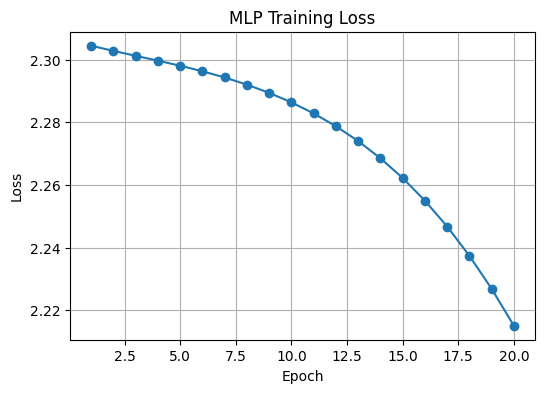

In [12]:
# Plot the loss
plt.figure(figsize=(6, 4))
plt.plot(range(1, epochs + 1), losses, marker='o')
plt.title("MLP Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

In [13]:
#pytorch
model = nn.Sequential(nn.Linear(784, 64),nn.ReLU(),
    nn.Linear(64, 10))

#the copies i created in upper cell will be used here 
with torch.no_grad():
    model[0].weight.copy_(torch.tensor(W1_initial.T))
    model[0].bias.copy_(torch.tensor(b1_initial.flatten()))

    model[2].weight.copy_(torch.tensor(W2_initial.T))
    model[2].bias.copy_(torch.tensor(b2_initial.flatten()))

In [14]:
X_torch = torch.tensor(X_batch, dtype=torch.float32)
y_torch = torch.tensor(y_batch, dtype=torch.long)

#Forward
output = model(X_torch)

#loss
loss = nn.CrossEntropyLoss()(output, y_torch)

#Backward
loss.backward()

In [15]:
#pytorch gradiet
dW1_torch = model[0].weight.grad.numpy().T
dW2_torch = model[2].weight.grad.numpy().T

In [16]:
#absolute differ
difference_W1 = np.max(np.abs(dW1 - dW1_torch))
difference_W2 = np.max(np.abs(dW2 - dW2_torch))

print("Maximum difference for W1:", difference_W1)
print("Maximum difference for W2:", difference_W2)


Maximum difference for W1: 0.006655703253986288
Maximum difference for W2: 0.030647578993040124
